In [ ]:
!nvidia-smi

Wed Jan 28 18:12:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.0 MB/s eta 0:00:00


In [ ]:
## connecting to the google drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/00_GradProject/YOLO/

/content/drive/MyDrive/00_GradProject/YOLO


In [ ]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 38.7/112.6 GB disk)


In [9]:
%cd /content/drive/MyDrive/00_GradProject/YOLO/

!yolo task=detect mode=train model=yolov8l.pt data=data.yaml epochs=50 imgsz=224 plots=True
# !yolo task=detect mode=train model=yolov8l.pt data="/content/drive/MyDrive/ObjectdetectionData/custom.yaml" epochs=100 imgsz=640 batch=8 project="/content/drive/MyDrive/ObjectdetectionData/training_results" name=resultsfinalLarge


/content/drive/MyDrive/00_GradProject/YOLO
Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

In [15]:
!ls runs/detect/train3


args.yaml			 results.csv	       val_batch0_labels.jpg
BoxF1_curve.png			 results.png	       val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg      val_batch1_labels.jpg
BoxPR_curve.png			 train_batch16240.jpg  val_batch1_pred.jpg
BoxR_curve.png			 train_batch16241.jpg  val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch16242.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch1.jpg      weights
labels.jpg			 train_batch2.jpg


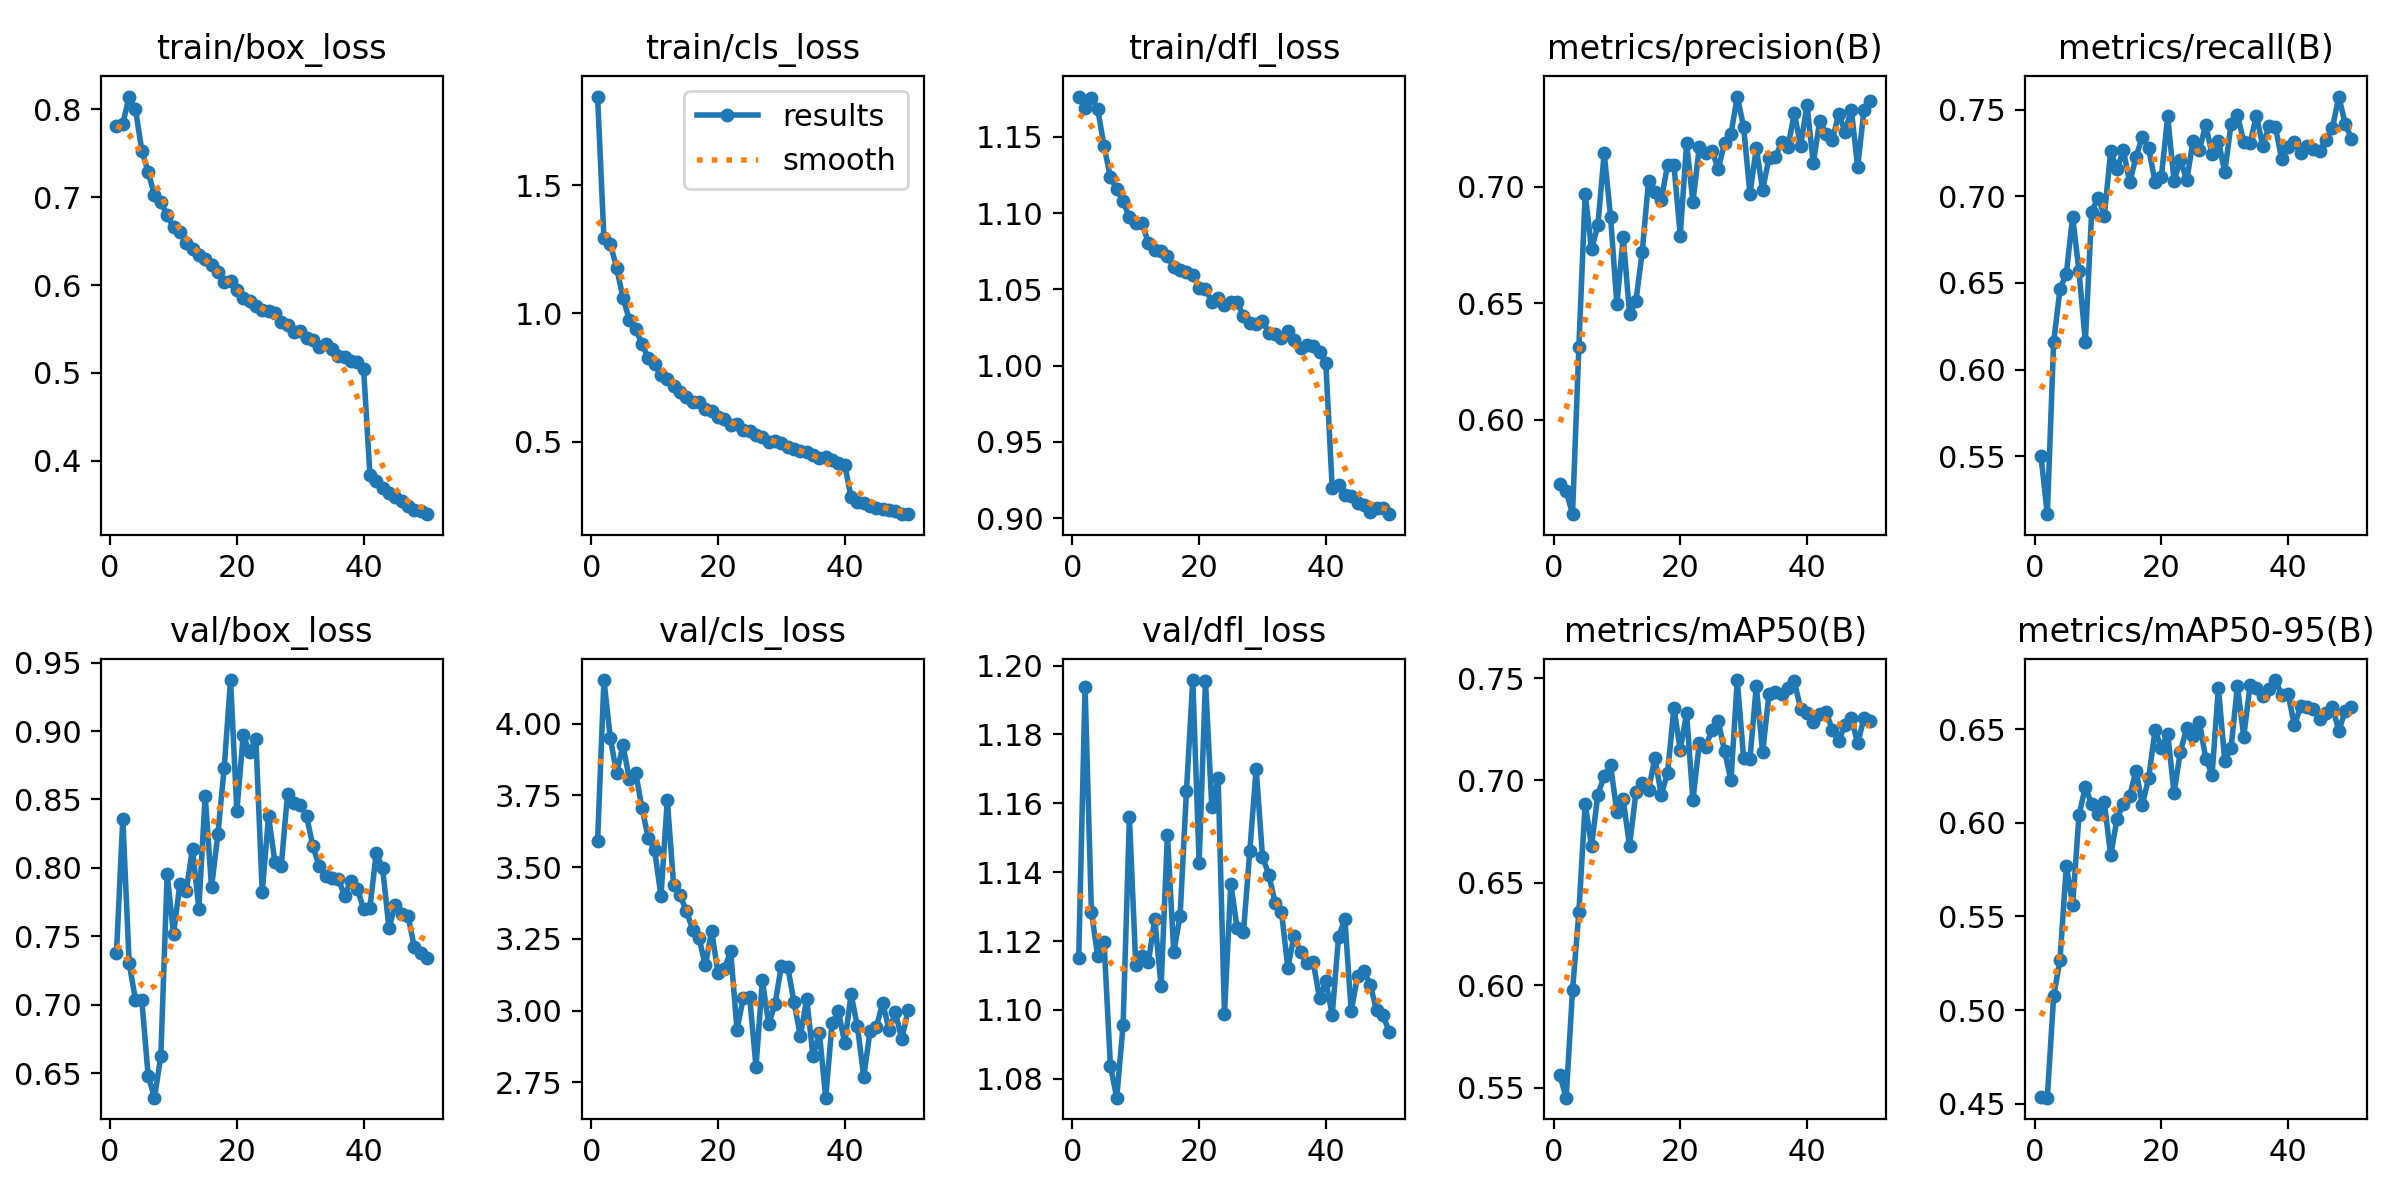

In [16]:
from IPython.display import Image
image_path = '/content/drive/MyDrive/00_GradProject/YOLO/runs/detect/train3/results.png'
Image(filename=image_path, width=600)

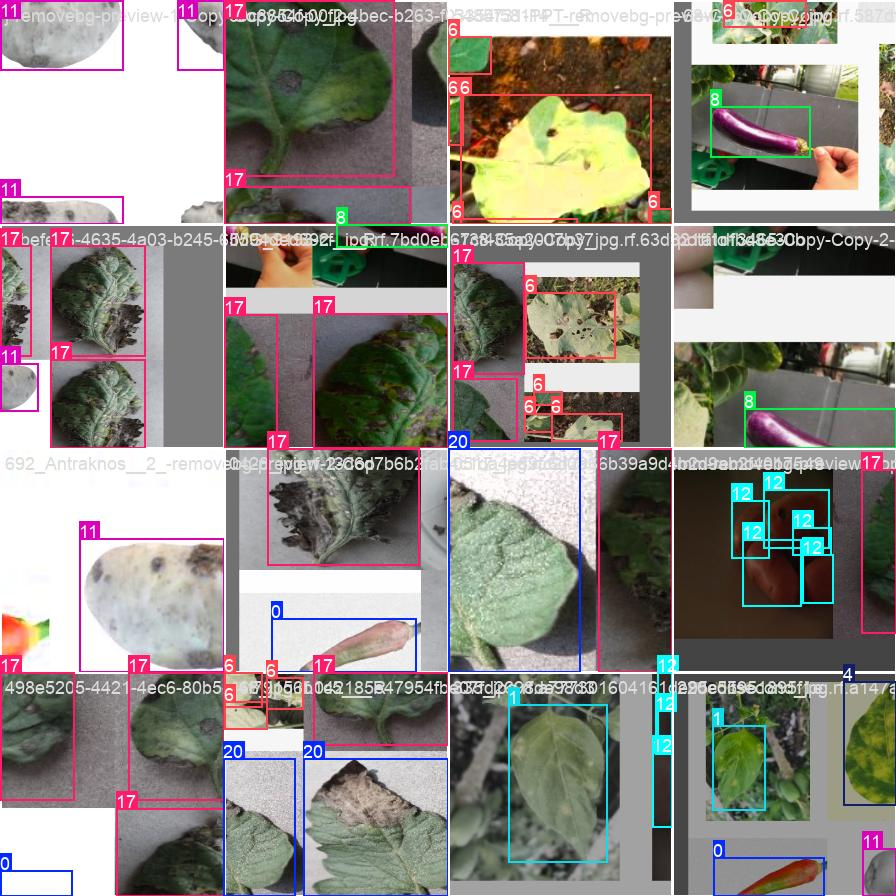

In [17]:
image_path = '/content/drive/MyDrive/00_GradProject/YOLO/runs/detect/train3/train_batch1.jpg'
Image(filename=image_path, width =600)

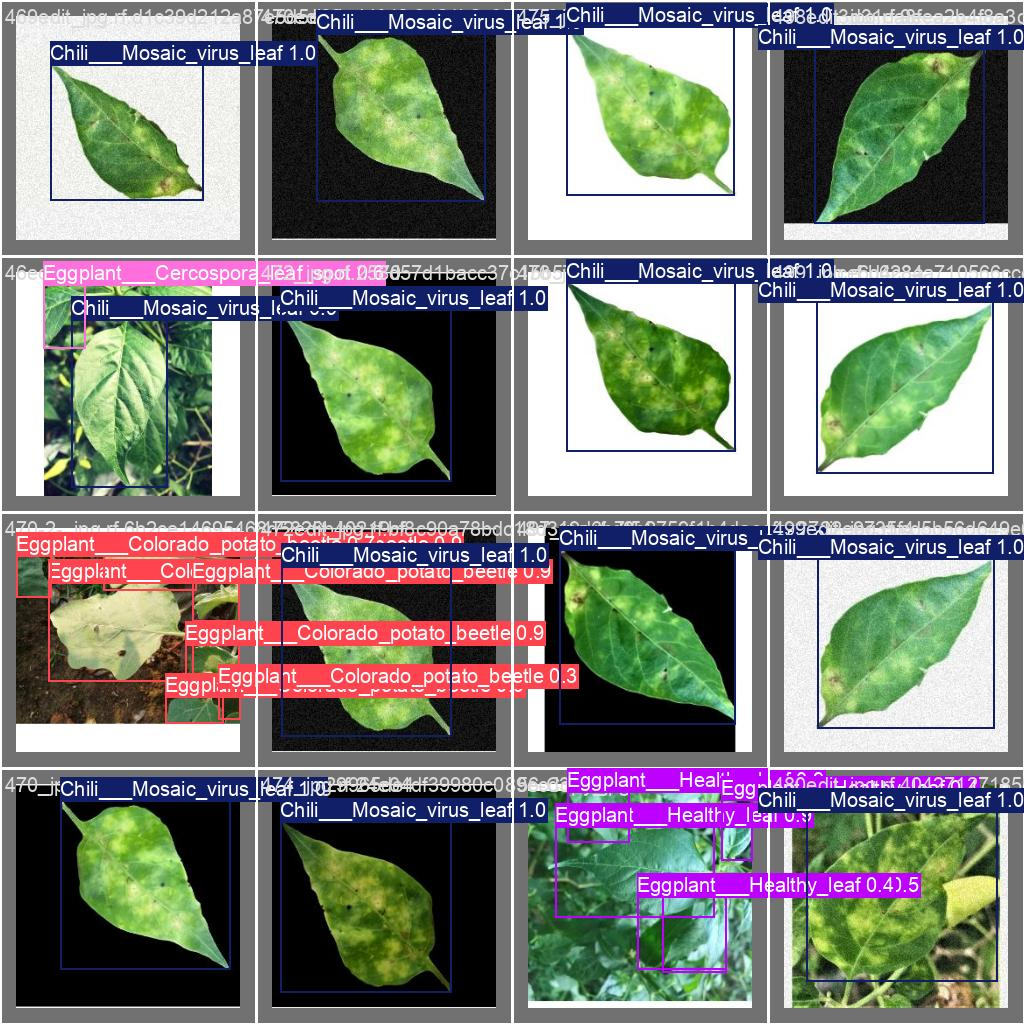

In [18]:
Image(filename='/content/drive/MyDrive/00_GradProject/YOLO/runs/detect/train3/val_batch1_pred.jpg', width=600)

In [19]:
!yolo task=detect mode=val model="/content/drive/MyDrive/00_GradProject/YOLO/runs/detect/train3/weights/best.pt" data=/content/drive/MyDrive/00_GradProject/YOLO/data.yaml

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 113 layers, 43,624,341 parameters, 0 gradients, 164.9 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 7.5±2.2 MB/s, size: 12.9 KB)
val: Scanning /content/drive/MyDrive/00_GradProject/YOLO/valid/labels.cache... 790 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 790/790 110.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 4.8it/s 10.4s
                   all        790       1249      0.731       0.74      0.749      0.677
 Chili___Healthy_fruit          9         11          1      0.761      0.872      0.716
  Chili___Healthy_leaf        350        508          0          0          0          0
Chili___Mosaic_virus_leaf        115        119       0.29      0.983      0.588      0.585
Eggplant___Cercospora_leaf_spot         70        100      0.918       0.82      0.908      0.794
Eggplant___C

## **Inference on Test images**

In [20]:
!yolo task=detect mode=predict model="/content/drive/MyDrive/00_GradProject/YOLO/runs/detect/train3/weights/best.pt" conf=0.25 source="/content/drive/MyDrive/00_GradProject/YOLO/test/images" save=True


Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 113 layers, 43,624,341 parameters, 0 gradients, 164.9 GFLOPs

image 1/771 /content/drive/MyDrive/00_GradProject/YOLO/test/images/0001_jpg.rf.b97ea38d8fe03ea312c7851f9039b8d9.jpg: 224x224 4 Tomato___Healthy_fruits, 18.7ms
image 2/771 /content/drive/MyDrive/00_GradProject/YOLO/test/images/0010_jpg.rf.8b55051b1f5efc858013ee6273fe7983.jpg: 224x224 2 Tomato___Healthy_fruits, 18.7ms
image 3/771 /content/drive/MyDrive/00_GradProject/YOLO/test/images/0016_jpg.rf.54f2a31410c691c2e4026bbfea52162c.jpg: 224x224 1 Potato___Healthy_fruit, 18.7ms
image 4/771 /content/drive/MyDrive/00_GradProject/YOLO/test/images/0017_jpg.rf.11880a73750461182c5a8ddea1df01f7.jpg: 224x224 4 Potato___Healthy_fruits, 18.7ms
image 5/771 /content/drive/MyDrive/00_GradProject/YOLO/test/images/0019_jpg.rf.c24a34798739d5ba088952972145f001.jpg: 224x224 3 Tomato___Healthy_fruits, 18.7ms
image 6/771 /content/drive/MyDrive/00_Gr

In [21]:
# !cp -r /content/runs/detect/predict /content/drive/MyDrive/ObjectdetectionData/test_results


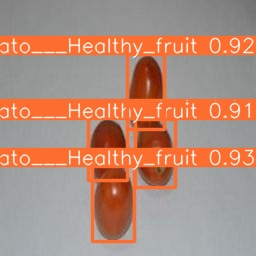

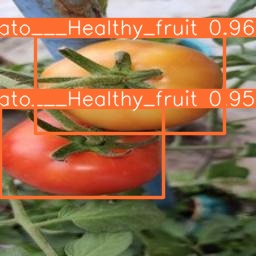

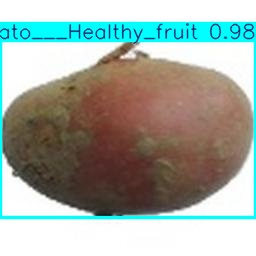

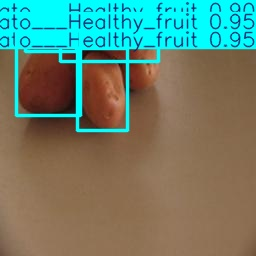

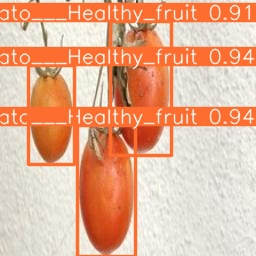

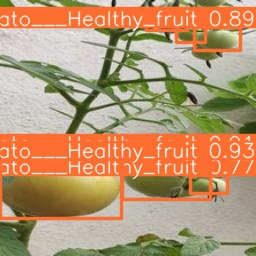

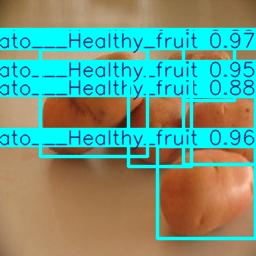

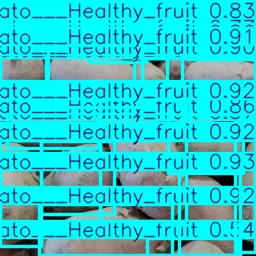

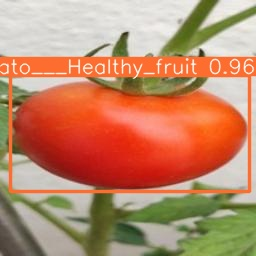

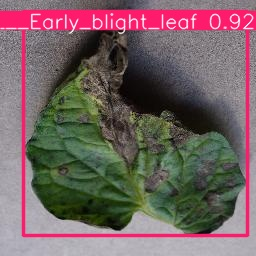

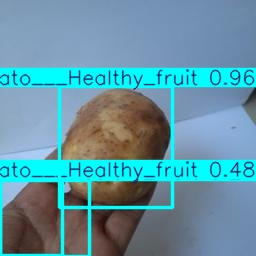

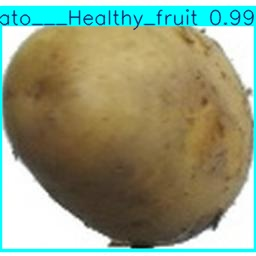

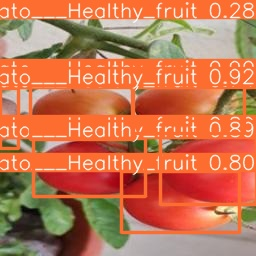

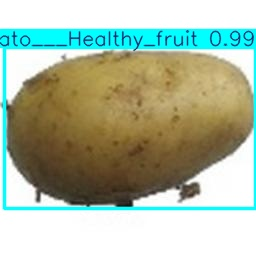

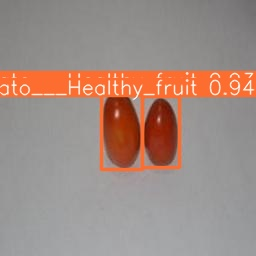

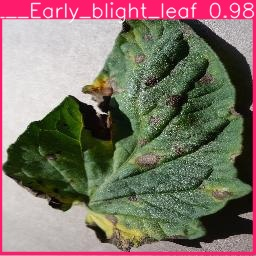

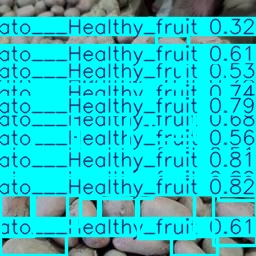

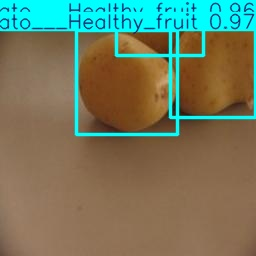

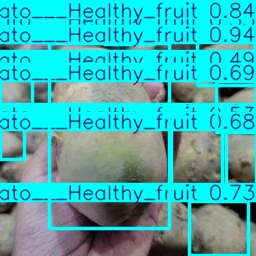

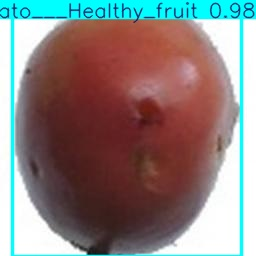

In [22]:
import glob
from IPython.display import Image, display

for image_path in glob.glob('runs/detect/predict/*.jpg')[:20]:
      display(Image(filename=image_path, width=600))
      print("\n")